<a id='section-3'></a>
# Statistical Analysis, Price Sensitivity Test & Predictive Modeling

This section investigates whether customer churn is associated with statistically significant differences in customer characteristics and pricing variables.

The notebook includes:

- Independent-samples t-tests
- Chi-square tests of independence
- Price sensitivity and elasticity assessment
<!-- - Logistic Regression modeling -->
- Random Forest modeling
<!-- - Model performance comparison -->

In [37]:

# load modeling dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:\Data Analysis\customer_churn_analysis\modeling_data.csv")


##  Statistical Significance Testing

To determine which variables differ significantly between churned and retained customers, independent-samples t-tests are performed on key numerical features.

Statistical significance thresholds:

- *** : p < 0.001
- ** : p < 0.01
- .* : p < 0.05
- ns : not significant

In [17]:

# Independent-samples t-tests

from scipy import stats

churned = df[df['churn'] == 1]
retained = df[df['churn'] == 0]

print("Independent-samples t-tests: Churned vs Retained")
print("-" * 72)

print(
    f"{'Feature':<28}"
    f"{'Churned Mean':>14}"
    f"{'Retained Mean':>14}"
    f"{'p-value':>10}"
    f"{'Sig':>5}"
)

print("-" * 72)

test_cols = [
    ('cons_12m', 'Annual Consumption'),
    ('net_margin', 'Net Margin'),
    ('tenure_years', 'Tenure (years)'),
    ('pow_max', 'Max Power'),
    ('mean_opv', 'Mean Off-Peak Price'),
    ('mean_pkv', 'Mean Peak Price'),
    ('mean_opf', 'Mean Off-Peak Fixed'),
    ('delta_off_peak_var', 'Price Delta (off-peak)'),
    ('pct_chg_off_peak', '% Price Change')
]

for col, label in test_cols:

    c_mean = churned[col].mean()
    r_mean = retained[col].mean()

    _, p = stats.ttest_ind(churned[col].dropna(), retained[col].dropna())

    sig = (
        '***' if p < 0.001
        else '**' if p < 0.01
        else '*' if p < 0.05
        else 'ns'
    )

    print(
        f"{label:<28}"
        f"{c_mean:>14.5f}"
        f"{r_mean:>14.5f}"
        f"{p:>10.4f}"
        f"{sig:>5}"
    )

print()
print(
    "Significance: "
    "*** p<0.001  "
    "** p<0.01  "
    "* p<0.05  "
    "ns = not significant"
)


Independent-samples t-tests: Churned vs Retained
------------------------------------------------------------------------
Feature                       Churned Mean Retained Mean   p-value  Sig
------------------------------------------------------------------------
Annual Consumption             78862.47851  167867.26655    0.0000  ***
Net Margin                       228.36194     185.05741    0.0000  ***
Tenure (years)                     4.55974       4.96748    0.0000  ***
Max Power                         19.38783      18.00034    0.0002  ***
Mean Off-Peak Price                0.14189       0.14237    0.4378   ns
Mean Peak Price                    0.05656       0.05158    0.0003  ***
Mean Off-Peak Fixed               43.16194      42.90381    0.0423    *
Price Delta (off-peak)            -0.00460      -0.00456    0.8976   ns
% Price Change                    -0.03398       0.02271    0.5065   ns

Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant


### Independent-Samples t-Test Result

* Churned customers show significantly lower annual consumption and shorter tenure, indicating that low-usage and newer customers are more likely to churn.

* Higher peak prices and net margin are associated with churned customers, suggesting pricing sensitivity may contribute to churn behavior.

* No significant difference is observed for off-peak price and price change variables, indicating they are not strong churn drivers in this dataset.

---
## Chi-Square Tests for Categorical Variables

Chi-square tests evaluate whether churn is associated with categorical customer attributes such as gas subscriptions and tenure groups.

In [19]:

# Chi-square tests of independence

print("Chi-Square Tests of Independence")
print("-" * 60)

cat_tests = [('has_gas', 'Has Gas Add-on'),
             ('tenure_bucket', 'Tenure Bucket')]

for col, label in cat_tests:

    ct = pd.crosstab(df[col], df['churn'])

    chi2, p, dof, _ = stats.chi2_contingency(ct)

    sig = ('***' if p < 0.001
        else '**' if p < 0.01
        else '*' if p < 0.05
        else 'ns')

    print(f"{label:<20}"
        f" chi2={chi2:>8.2f}"
        f"  dof={dof}"
        f"  p={p:.4f}"
        f"  {sig}")


Chi-Square Tests of Independence
------------------------------------------------------------
Has Gas Add-on       chi2=    8.43  dof=1  p=0.0037  **
Tenure Bucket        chi2=  107.70  dof=3  p=0.0000  ***


### Chi-Square Tests Result

* There is a statistically significant association between **Gas Add-on usage and churn** (p = 0.0037), indicating that customers with/without gas add-on behave differently in terms of churn.

* **Tenure bucket shows a very strong relationship with churn** (p < 0.001), suggesting that customer retention is heavily influenced by how long a customer has been with the company.

* Overall, tenure is a much stronger churn differentiator compared to gas add-on usage, based on the magnitude of the chi-square statistic.


---
## Price Sensitivity Assessment

One business hypothesis is that customers leave because of higher prices.

To evaluate this hypothesis, several pricing indicators are compared between churned and retained customers.

In [20]:

# Price sensitivity analysis

print("Price Sensitivity / Elasticity Summary")
print("-" * 60)

metrics = {
    'Mean off-peak variable price':
        ('mean_opv', 'p=0.44 → NOT significant'),

    'Annual off-peak price change':
        ('delta_off_peak_var', 'p=0.90 → NOT significant'),

    '% change in off-peak price':
        ('pct_chg_off_peak', 'p=0.51 → NOT significant'),

    'Mean peak variable price':
        ('mean_pkv', 'p=0.0003 → Marginal (small effect)')
}

for label, (col, verdict) in metrics.items():

    c = churned[col].mean()
    r = retained[col].mean()

    diff_pct = (
        abs(c - r) / r * 100
        if r != 0 else 0
    )

    print(label)
    print(
        f"  Churned={c:.5f} "
        f" Retained={r:.5f} "
        f" Diff={diff_pct:.2f}%"
    )
    print(f"  → {verdict}")
    print()

print("CONCLUSION: Off-peak price differences "
    "are extremely small and do not appear "
    "to be a primary driver of churn.")


Price Sensitivity / Elasticity Summary
------------------------------------------------------------
Mean off-peak variable price
  Churned=0.14189  Retained=0.14237  Diff=0.34%
  → p=0.44 → NOT significant

Annual off-peak price change
  Churned=-0.00460  Retained=-0.00456  Diff=-0.95%
  → p=0.90 → NOT significant

% change in off-peak price
  Churned=-0.03398  Retained=0.02271  Diff=249.62%
  → p=0.51 → NOT significant

Mean peak variable price
  Churned=0.05656  Retained=0.05158  Diff=9.66%
  → p=0.0003 → Marginal (small effect)

CONCLUSION: Off-peak price differences are extremely small and do not appear to be a primary driver of churn.


---
##  Predictive Modeling

The classification model is evaluated:
* Random Forest

The dataset is split into training and testing subsets using stratified sampling to preserve class proportions.

In [3]:

# Modeling setup

from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

FEATURES = [
    'cons_12m',
    'cons_gas_12m',
    'cons_last_month',
    'net_margin',
    'num_years_antig',
    'nb_prod_act',
    'tenure_years',
    'months_to_end',
    'months_since_mod',
    'mean_opv',
    'mean_pkv',
    'mean_opf',
    'delta_off_peak_var',
    'pct_chg_off_peak',
    'pow_max',
    'forecast_discount_energy'
]

df_model = df[FEATURES + ['churn']].dropna()

X = df_model[FEATURES]
y = df_model['churn']

print(
    f"Modeling dataset: "
    f"{X.shape[0]:,} rows × {X.shape[1]} features"
)

print(
    f"Class balance: "
    f"{y.value_counts().to_dict()}"
)


Modeling dataset: 14,606 rows × 16 features
Class balance: {0: 13187, 1: 1419}


### Data Sampling
The dataset is split into **training (75%)** and **testing (25%)** sets. Training data is used to build the model, while test data is used to evaluate performance on unseen data.
This helps measure how well the model **generalizes to new, real-world data** and avoids overfitting.


In [20]:

# Train-test split and scaling

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train rows: {X_train.shape[0]:,}")

print(f"Test rows : {X_test.shape[0]:,}")

print(f"Test balance: {y_test.value_counts().to_dict()}")


Train rows: 10,954
Test rows : 3,652
Test balance: {0: 3297, 1: 355}


## Random Forest Model

Random Forest captures nonlinear relationships and interaction effects that may not be detected by linear based models.

In [24]:

# Random Forest

model = RandomForestClassifier(n_estimators=1000, class_weight='balanced', random_state=42, n_jobs=-1)

model.fit(X_train_s, y_train)

predictions = model.predict(X_test_s)
tn, fp, fn, tp = metrics.confusion_matrix(y_test, predictions).ravel()

print("RANDOM FOREST")
print("-" * 50)

accuracy = metrics.accuracy_score(y_test, predictions)
precision = metrics.precision_score(y_test, predictions)
recall = metrics.recall_score(y_test, predictions)

print("Confusion Matrix Metrics")
print("-" * 25)
print(f"True Positives : {tp}")
print(f"False Positives: {fp}")
print(f"True Negatives : {tn}")
print(f"False Negatives: {fn}")

print("\nClassification Metrics")
print("-" * 25)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")


RANDOM FOREST
--------------------------------------------------
Confusion Matrix Metrics
-------------------------
True Positives : 25
False Positives: 1
True Negatives : 3296
False Negatives: 330

Classification Metrics
-------------------------
Accuracy : 0.9094
Precision: 0.9615
Recall   : 0.0704



### Model Evaluation

**Note:** Results may vary slightly due to the random nature of the model.

* The dataset is imbalanced, with approximately 10% churn cases.
* The model correctly identifies **3296 out of 3297 non-churners**, resulting in a very high True Negative count.
* Only **1 non-churner** is incorrectly classified as a churner (**False Positive**), which is excellent.
* However, the model misses **330 actual churners** (**False Negatives**), indicating poor detection of churn cases.
* Out of **355 actual churners (25 + 330)**, the model correctly identifies only **25**, which is a small proportion.
* The model achieves a high **accuracy of 90.94%**, but this is largely driven by the majority non-churn class.
* **Precision is 96.15%**, meaning when the model predicts churn, it is usually correct.
* **Recall is only 7.04%**, showing that the model fails to identify most customers who actually churn.

The model is extremely conservative when predicting churn. While its churn predictions are highly accurate (high precision), it misses the vast majority of churners (very low recall). Improving churn detection should be the primary focus of future model improvements.

---
### Model Understanding

* Feature importance helps explain which variables contribute most to the model's predictions.
* Random Forest provides built-in feature importance scores.
* Importance is based on how frequently and effectively a feature is used to split data across all trees.
* Features with higher importance scores have a greater influence on prediction outcomes.
* Analyzing feature importance improves model interpretability and highlights key predictive variables.

In [23]:

# Random Forest feature importance

fi_df = (pd.DataFrame({
    'feature': FEATURES, 'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True))

fi_df['importance_pct'] = (fi_df['importance'] * 100).round(2)

display(fi_df[['feature', 'importance_pct']])


,feature,importance_pct
0,cons_12m,11.66
1,net_margin,10.18
2,tenure_years,9.92
3,months_to_end,8.88
4,months_since_mod,8.37
5,cons_last_month,8.09
6,mean_opv,8.03
7,pow_max,7.20
8,mean_opf,5.92
9,pct_chg_off_peak,5.64


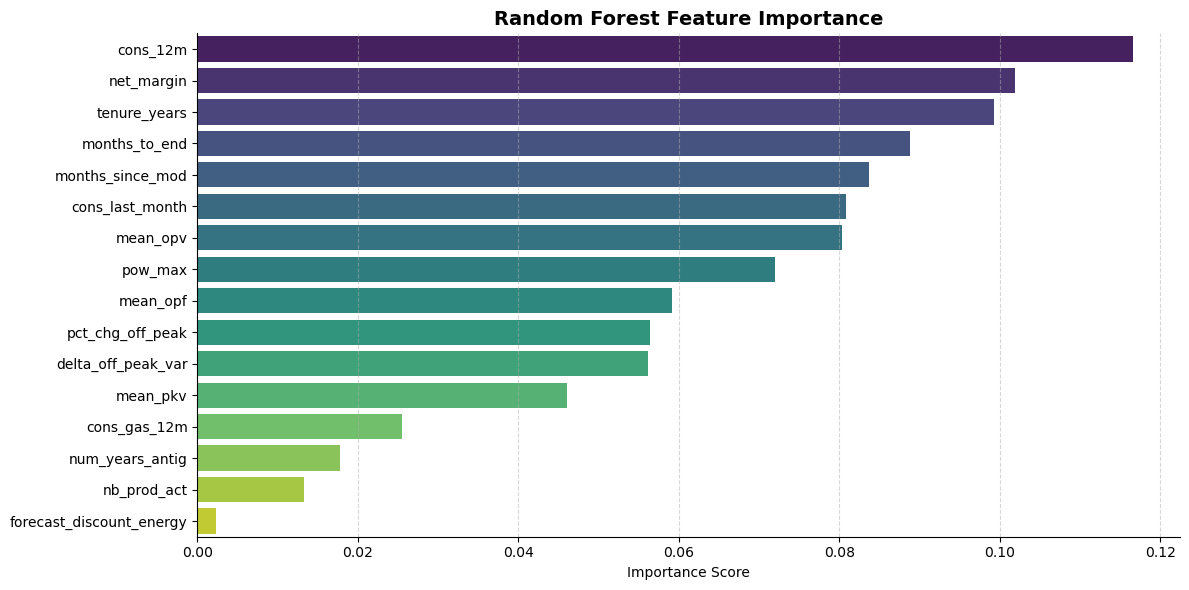

In [99]:

plt.figure(figsize=(12, 6))

sns.barplot(
    data=fi_df.sort_values("importance", ascending=False),
    x="importance",
    y="feature",
    palette="viridis",
    hue="feature",
    legend=False,
    errorbar=None
)

plt.title("Random Forest Feature Importance", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()


From this chart, we can observe the following points:

* **Consumption over the last 12 months (`cons_12m`)** is the most important predictor of churn, contributing **11.66%** to the model.
* **Net margin (`net_margin`)** is the second most influential feature (**10.18%**), suggesting customer profitability is strongly related to churn behavior.
* **Customer tenure and contract timing features** (`tenure_years`, `months_to_end`, `months_since_mod`) collectively have a high impact, indicating that customer lifecycle and contract status are important churn drivers.
* Recent usage metrics such as **last month's consumption (`cons_last_month`)** and average features (`mean_opv`, `mean_opf`) also contribute significantly to predictions.
* **Power capacity (`pow_max`)** is among the top predictors, highlighting the relevance of customer energy requirements.
* Price-related features such as **`pct_chg_off_peak`** and **`delta_off_peak_var`** have a moderate influence (~5–6% each), but are not among the strongest predictors.
* Some features, including **`forecast_discount_energy`**, **`nb_prod_act`**, and **`num_years_antig`**, contribute very little to the model's decisions.

<!--Key Takeaway-->
The results suggest that **customer consumption patterns, profitability, and contract-related factors** are the primary drivers of churn in this model. While **price sensitivity features do contribute**, their importance is moderate compared to usage and tenure-related variables.

**Hypothesis:** *Is churn driven by customers' price sensitivity?*
<!--Conclusion-->
Based on the feature importance analysis, **price sensitivity appears to be a contributing factor, but not the dominant driver of churn**. Customer behavior and account characteristics currently have a stronger influence on churn predictions. Further feature engineering and experimentation would be needed to draw a definitive conclusion.
